In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
panel_df = pd.read_csv("../data/clean/panel_verify.csv")

In [3]:
cvd_all = panel_df[panel_df['Topic']=='Cardiovascular Disease']
for year in [2019, 2020, 2021, 2022, 2023]:
    y = cvd_all[cvd_all['YearStart']==year]
    print(year, 
          'total:', len(y),
          'prev:', y['prevalence'].notna().sum(),
          'mort:', y['mortality'].notna().sum(),
          'both:', (y['prevalence'].notna() & y['mortality'].notna()).sum())

2019 total: 53 prev: 52 mort: 51 both: 50
2020 total: 51 prev: 0 mort: 51 both: 0
2021 total: 54 prev: 53 mort: 51 both: 50
2022 total: 51 prev: 0 mort: 51 both: 0
2023 total: 52 prev: 52 mort: 0 both: 0


In [4]:
for topic in panel_df['Topic'].unique():
    d = panel_df[panel_df['Topic']==topic]
    for year in [2019, 2020, 2021, 2022, 2023]:
        y = d[d['YearStart']==year]
        both = (y['prevalence'].notna() & y['mortality'].notna()).sum()
        print(topic, year, 'both:', both)
    print()

Asthma 2019 both: 37
Asthma 2020 both: 39
Asthma 2021 both: 37
Asthma 2022 both: 39
Asthma 2023 both: 0

Cardiovascular Disease 2019 both: 50
Cardiovascular Disease 2020 both: 0
Cardiovascular Disease 2021 both: 50
Cardiovascular Disease 2022 both: 0
Cardiovascular Disease 2023 both: 0

Chronic Obstructive Pulmonary Disease 2019 both: 50
Chronic Obstructive Pulmonary Disease 2020 both: 51
Chronic Obstructive Pulmonary Disease 2021 both: 50
Chronic Obstructive Pulmonary Disease 2022 both: 51
Chronic Obstructive Pulmonary Disease 2023 both: 0

Diabetes 2019 both: 50
Diabetes 2020 both: 51
Diabetes 2021 both: 50
Diabetes 2022 both: 51
Diabetes 2023 both: 0



In [5]:
panel_df['hospitalization'] = panel_df['hospitalization'] * 100
panel_df['hospitalization_lo'] = panel_df['hospitalization_lo'] * 100
panel_df['hospitalization_hi'] = panel_df['hospitalization_hi'] * 100

In [6]:
panel_df.head(10)

,LocationAbbr,YearStart,Topic,hospitalization,mortality,prevalence,hospitalization_lo,mortality_lo,prevalence_lo,hospitalization_hi,mortality_hi,prevalence_hi
0,AK,2019,Asthma,NaN,NaN,10.5,NaN,NaN,8.9,NaN,NaN,12.4
1,AK,2019,Cardiovascular Disease,980.0,129.7,32.8,905.0,120.5,30.4,1055.0,138.9,35.3
2,AK,2019,Chronic Obstructive Pulmonary Disease,366.0,81.7,4.6,320.0,69.4,3.7,412.0,93.9,5.6
3,AK,2019,Diabetes,NaN,45.8,7.2,NaN,40.4,6.1,NaN,51.2,8.5
4,AK,2020,Asthma,NaN,NaN,9.8,NaN,NaN,8.4,NaN,NaN,11.5
5,AK,2020,Cardiovascular Disease,869.0,139.8,NaN,800.0,130.4,NaN,938.0,149.3,NaN
6,AK,2020,Chronic Obstructive Pulmonary Disease,164.0,81.8,4.6,135.0,69.5,3.8,194.0,94.1,5.5
7,AK,2020,Diabetes,NaN,65.8,7.4,NaN,59.5,6.4,NaN,72.2,8.6
8,AK,2021,Asthma,NaN,NaN,9.9,NaN,NaN,8.8,NaN,NaN,11.2
9,AK,2021,Cardiovascular Disease,953.0,154.7,29.9,881.0,144.6,28.3,1024.0,164.8,31.6


Text(0, 0.5, 'Mortality')

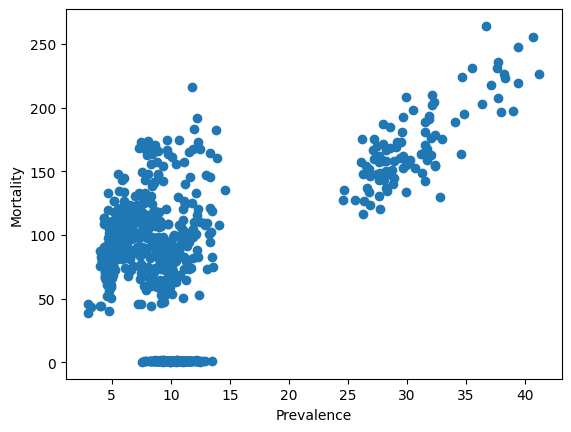

In [7]:
plt.scatter(panel_df['prevalence'],panel_df['mortality'])
plt.xlabel('Prevalence')
plt.ylabel('Mortality')

In [8]:
# Let's focus only on Cardiovascular disease and Chronic Obstructive Pulmonary Disease but analyze for all 4 because
# CMS data is not available for Diabetes and Asthma

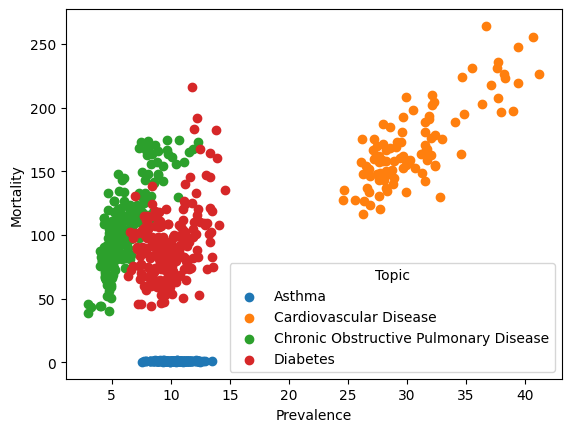

In [9]:
for name, group in panel_df.groupby('Topic'):
    plt.scatter(group['prevalence'], group['mortality'], label=name)

plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.legend(title='Topic')

Text(0.5, 1.0, 'Prevalence vs Mortality for Asthma')

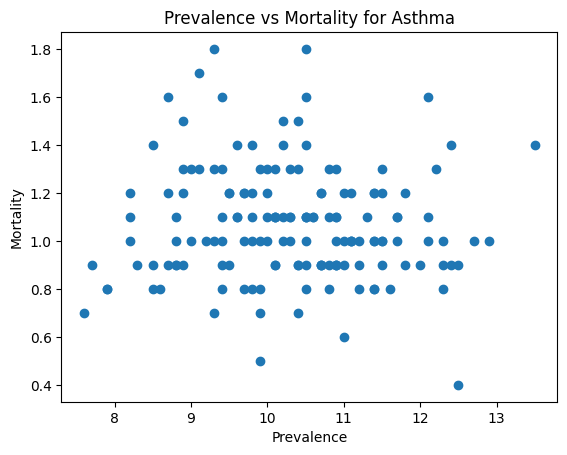

In [10]:
asthma = panel_df.loc[panel_df['Topic'] == 'Asthma']
plt.scatter(asthma['prevalence'], asthma['mortality'])
plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.title('Prevalence vs Mortality for Asthma')

Text(0.5, 1.0, 'Prevalence vs Mortality for Cardiovascular Disease')

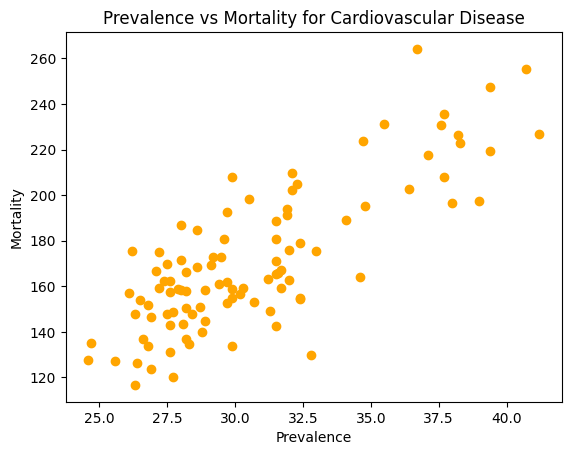

In [11]:
cvd = panel_df.loc[panel_df['Topic'] == 'Cardiovascular Disease']
plt.scatter(cvd['prevalence'], cvd['mortality'], color='orange')
plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.title('Prevalence vs Mortality for Cardiovascular Disease')

Text(0.5, 1.0, 'Prevalence vs Mortality for Chronic Obstructive Pulmonary Disease')

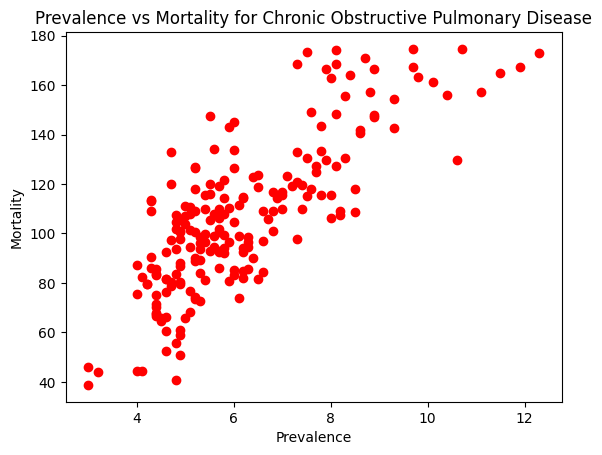

In [12]:
copd = panel_df.loc[panel_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']
plt.scatter(copd['prevalence'], copd['mortality'], color='red')
plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.title('Prevalence vs Mortality for Chronic Obstructive Pulmonary Disease')

Text(0.5, 1.0, 'Prevalence vs Mortality for Diabetes')

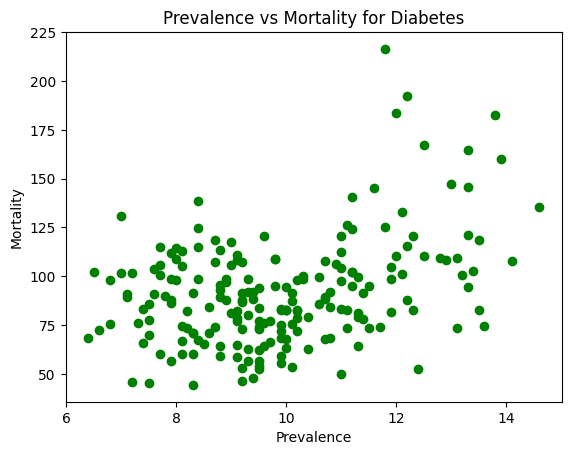

In [13]:
diabetes = panel_df.loc[panel_df['Topic'] == 'Diabetes']
plt.scatter(diabetes['prevalence'], diabetes['mortality'], color='green')
plt.xlabel('Prevalence')
plt.ylabel('Mortality')
plt.title('Prevalence vs Mortality for Diabetes')

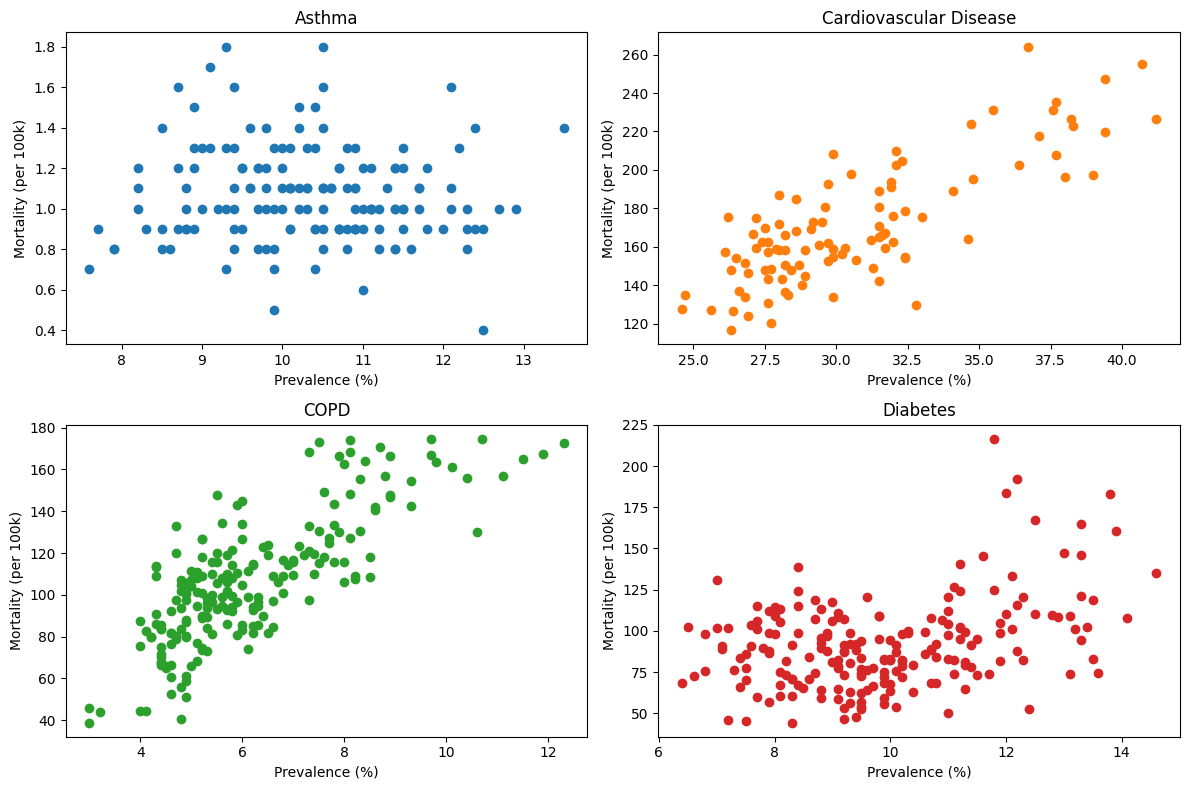

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

d = panel_df[panel_df['Topic'] == 'Asthma']
axes[0,0].scatter(d['prevalence'], d['mortality'], color='tab:blue')
axes[0,0].set_title('Asthma')

d = panel_df[panel_df['Topic'] == 'Cardiovascular Disease']
axes[0,1].scatter(d['prevalence'], d['mortality'], color='tab:orange')
axes[0,1].set_title('Cardiovascular Disease')

d = panel_df[panel_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']
axes[1,0].scatter(d['prevalence'], d['mortality'], color='tab:green')
axes[1,0].set_title('COPD')

d = panel_df[panel_df['Topic'] == 'Diabetes']
axes[1,1].scatter(d['prevalence'], d['mortality'], color='tab:red')
axes[1,1].set_title('Diabetes')

for ax in axes.flat:
    ax.set_xlabel('Prevalence (%)')
    ax.set_ylabel('Mortality (per 100k)')
plt.tight_layout()
plt.show()

In [15]:
# Verify OK outlier
ok_cvd = panel_df.loc[(panel_df['LocationAbbr']=='OK') & (panel_df['Topic']=='Cardiovascular Disease') & (panel_df['YearStart']==2019)]
print(ok_cvd[['LocationAbbr', 'mortality', 'mortality_lo', 'mortality_hi']])

    LocationAbbr  mortality  mortality_lo  mortality_hi
734           OK      231.4         227.0         235.8


In [16]:
from sklearn.linear_model import LinearRegression

In [17]:
output_groups = []

panel_2021 = panel_df[panel_df['YearStart'] == 2019]

for disease, group in panel_2021.groupby('Topic'):
    
    clean_group = group.dropna(subset=["prevalence", "mortality"]).copy()
    print(disease, len(clean_group))
    
    if len(clean_group) == 0:
        continue
    X = clean_group[['prevalence']]
    y = clean_group['mortality']
    model = LinearRegression()
    model.fit(X,y)

    clean_group['prediction'] = model.predict(X)
    residual = y - clean_group['prediction']
    clean_group['residual'] = residual

    if clean_group['residual'].std() > 0:
        clean_group['residual_z_score'] = (clean_group['residual'] - clean_group['residual'].mean()) / clean_group['residual'].std()
    else:
        clean_group['residual_z_score'] = 0.0
    output_groups.append(clean_group)

results_df = pd.concat(output_groups)
        
    



Asthma 37
Cardiovascular Disease 50
Chronic Obstructive Pulmonary Disease 50
Diabetes 50


In [ ]:
results_df

In [19]:
# Let's focus on each disease at a time

results_df = results_df.rename(columns={'prevalence': 'prevalence %', 'mortality': 'mortality per 100k'})

diabetes_res = results_df.loc[results_df['Topic'] == 'Diabetes']


diabetes_agg = diabetes_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score', 'hospitalization']].sort_values('residual_z_score')
diabetes_best = diabetes_agg.head(5)
diabetes_best

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
23,AL,2019,12.4,52.6,84.306543,-31.706543,-1.789016,NaN
163,DE,2019,11.0,50.2,78.578710,-28.378710,-1.601245,NaN
123,CT,2019,8.3,44.4,67.532176,-23.132176,-1.305214,NaN
300,IL,2019,10.1,53.6,74.896532,-21.296532,-1.201639,NaN
183,FL,2019,9.5,52.6,72.441747,-19.841747,-1.119554,NaN


In [20]:
diabetes_worst = diabetes_agg.tail(5).iloc[::-1]
diabetes_worst

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score,hospitalization
736,OK,2019,11.2,140.4,79.396972,61.003028,3.442046,NaN
360,KY,2019,11.8,125.1,81.851757,43.248243,2.440246,NaN
516,MS,2019,13.5,118.5,88.806982,29.693018,1.675404,NaN
476,MN,2019,7.9,87.9,65.895653,22.004347,1.241577,NaN
756,OR,2019,7.5,85.9,64.259129,21.640871,1.221068,NaN


In [21]:
# COPD best/worst
copd_res = results_df.loc[results_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']
copd_agg = copd_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score']].sort_values('residual_z_score')
copd_best = copd_agg.head(5)
copd_best

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score
142,DC,2019,4.9,50.8,95.092429,-44.292429,-2.324100
239,HI,2019,4.0,44.5,82.747815,-38.247815,-2.006929
375,LA,2019,8.2,107.6,140.356014,-32.756014,-1.718765
162,DE,2019,7.3,97.6,128.011400,-30.411400,-1.595739
695,NY,2019,5.2,74.4,99.207301,-24.807301,-1.301682


In [23]:
copd_worst = copd_agg.tail(5).iloc[::-1]
copd_worst

,LocationAbbr,YearStart,prevalence %,mortality per 100k,prediction,residual,residual_z_score
279,ID,2019,4.7,133.0,92.349182,40.650818,2.133018
735,OK,2019,8.1,174.2,138.984390,35.215610,1.847824
1039,WY,2019,6.0,144.9,110.180291,34.719709,1.821803
535,MT,2019,5.9,143.0,108.808667,34.191333,1.794078
595,NE,2019,5.2,126.8,99.207301,27.592699,1.447836


In [ ]:
# Asthma

results_df = results_df.rename(columns={'prevalence': 'prevalence %', 'mortality': 'mortality per 100k'})

Asthma_res = results_df.loc[results_df['Topic'] == 'Asthma']


Asthma_agg = Asthma_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score', 'hospitalization']].sort_values('residual_z_score')
Asthma_best = Asthma_agg.head(5)
Asthma_best

In [ ]:
Asthma_worst = Asthma_agg.tail(5).iloc[::-1]
Asthma_worst

In [ ]:
# Cardiovascular Disease (CVD)

results_df = results_df.rename(columns={'prevalence': 'prevalence %', 'mortality': 'mortality per 100k'})

cvd_res = results_df.loc[results_df['Topic'] == 'Cardiovascular Disease']


cvd_agg = cvd_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score', 'hospitalization']].sort_values('residual_z_score')
cvd_best = cvd_agg.head(5)
cvd_best

In [ ]:
# Hospitalization vs Residual COPD

copd_hos = results_df.loc[results_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']
plt.scatter(copd_hos['hospitalization'], copd_hos['residual'], color='red')
plt.xlabel('Hospitalization per 100k')
plt.ylabel('Residual')

print(copd_hos[['hospitalization', 'residual']].corr())

In [ ]:
# Hospitalization vs Residual CVD

covd_hos = results_df.loc[results_df['Topic'] == 'Cardiovascular Disease']
plt.scatter(covd_hos['hospitalization'], covd_hos['residual'], color='green')
plt.xlabel('Hospitalization per 100k')
plt.ylabel('Residual')

covd_hos[['hospitalization', 'residual']].corr()

In [ ]:
# COPD linearity check
plt.scatter(copd_res['prediction'], copd_res['residual'])
plt.axhline(0)
plt.xlabel('Predicted mortality')
plt.ylabel('Residual')
plt.title('COPD residuals vs predictions')

In [ ]:
cvd_worst = cvd_agg.tail(5).iloc[::-1]
cvd_worst

In [ ]:
# Chronic Obstructive Pulmonary Disease (COPD)

results_df = results_df.rename(columns={'prevalence': 'prevalence %', 'mortality': 'mortality per 100k'})

copd_res = results_df.loc[results_df['Topic'] == 'Chronic Obstructive Pulmonary Disease']


copd_agg = copd_res[['LocationAbbr', 'YearStart', 'prevalence %', 'mortality per 100k', 'prediction', 'residual', 'residual_z_score', 'hospitalization']].sort_values('residual_z_score')
copd_best = copd_agg.head(5)
copd_best

In [ ]:
copd_worst = copd_agg.tail(5).iloc[::-1]
copd_worst

In [ ]:
panel_df.head()

In [ ]:
# Comparing the best and worst with Hospitalization records

In [ ]:
cvd_rates = pd.concat([cvd_best, cvd_worst], ignore_index=True)
cvd_rates

In [ ]:
plt.scatter(cvd_res['prediction'], cvd_res['residual'])
plt.axhline(0)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

diseases_colors = [
    ('Asthma', 'tab:blue'),
    ('Cardiovascular Disease', 'tab:orange'),
    ('Chronic Obstructive Pulmonary Disease', 'tab:green'),
    ('Diabetes', 'tab:red')
]

for ax, (disease, color) in zip(axes.flat, diseases_colors):
    d = results_df[results_df['Topic'] == disease].sort_values('prevalence %')
    ax.scatter(d['prevalence %'], d['mortality per 100k'], color=color)
    ax.plot(d['prevalence %'], d['prediction'], color='black', linewidth=1.5)
    ax.set_xlabel('Prevalence (%)')
    ax.set_ylabel('Mortality (per 100k)')
    ax.set_title(disease if disease != 'Chronic Obstructive Pulmonary Disease' else 'COPD')

plt.tight_layout()
plt.show()